# 3B.2 Self-Consistency - Reliability Test

## Objective
Test how **deterministic** or **noisy** the LLM Judge is when given the same input multiple times.

## Methodology

1. Select a subset of comparison pairs
2. Run each pair through the judge **5 times** with `temperature > 0`
3. Calculate **standard deviation** of consistency scores for each pair
4. Determine if the judge is reliable (low variance) or noisy (high variance)


In [21]:
# Setup and Imports
import os
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict
from dotenv import load_dotenv

# Load API key from root .env file
load_dotenv(Path("../.env"))

from google import genai
from google.genai import types

client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))
MODEL = "gemini-2.5-flash-lite"

# Experiment parameters
NUM_RUNS = 5
TEMPERATURE = 0.5  # > 0 to introduce variability

print(f"✓ Using model: {MODEL}")
print(f"✓ Runs per pair: {NUM_RUNS}")
print(f"✓ Temperature: {TEMPERATURE}")

# Load all 3 Prompt Templates from .md files (same as 3Ba)
PROMPT_DIR = Path("prompts")

def load_prompt(filename: str) -> str:
    filepath = PROMPT_DIR / filename
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read().strip()

ZERO_SHOT_PROMPT = load_prompt("Zero_Shot_Prompt.md")
COT_PROMPT = load_prompt("CoT_Prompt.md")
FEW_SHOT_PROMPT = load_prompt("Few_Shot_Prompt.md")

PROMPTS = {
    'zero_shot': ZERO_SHOT_PROMPT,
    'chain_of_thought': COT_PROMPT,
    'few_shot': FEW_SHOT_PROMPT
}

print(f"✓ Loaded {len(PROMPTS)} prompt strategies: {list(PROMPTS.keys())}")


✓ Using model: gemini-2.5-flash-lite
✓ Runs per pair: 5
✓ Temperature: 0.5
✓ Loaded 3 prompt strategies: ['zero_shot', 'chain_of_thought', 'few_shot']


In [19]:
# Load Comparison Pairs from comparisons.json
COMPARISONS_PATH = Path("comparisons.json")

with open(COMPARISONS_PATH, 'r', encoding='utf-8') as f:
    comparison_pairs = json.load(f)

print(f"✓ Loaded {len(comparison_pairs)} comparison pairs from comparisons.json")

# Show sample
print(f"\nEvents covered: {set(p['event'] for p in comparison_pairs)}")
print(f"Sample pair: {comparison_pairs[0]['event']} - {comparison_pairs[0]['author_name']}")


✓ Loaded 20 comparison pairs from comparisons.json

Events covered: {'Fort Sumter Decision', 'Election Night 1860', 'Gettysburg Address', 'Second Inaugural Address'}
Sample pair: Election Night 1860 - Francis F. Browne


In [22]:
# LLM Judge Function (updated to use prompt_type like 3Ba)
def call_judge(pair: Dict, prompt_type: str, temperature: float = 0.5) -> Dict:
    """Call the LLM judge with specified prompt type and temperature."""
    prompt_template = PROMPTS[prompt_type]
    
    lincoln_claims_str = "\n".join(f"- {c}" for c in pair['lincoln_claims'])
    author_claims_str = "\n".join(f"- {c}" for c in pair['author_claims'])
    
    prompt = prompt_template.format(
        event_name=pair['event'],
        lincoln_claims=lincoln_claims_str,
        author_claims=author_claims_str,
        author_name=pair['author_name']
    )
    
    try:
        response = client.models.generate_content(
            model=MODEL,
            contents=prompt,
            config=types.GenerateContentConfig(
                temperature=temperature,
                response_mime_type="application/json"
            )
        )
        
        raw_text = response.text.strip()
        result = json.loads(raw_text)
        result['error'] = None
        return result
        
    except Exception as e:
        return {
            "consistency_score": None,
            "error": str(e)
        }

print("✓ Judge function defined (with prompt_type parameter)")


✓ Judge function defined (with prompt_type parameter)


## Run Self-Consistency Experiment

For each pair, run the judge 5 times with temperature=0.5


In [ ]:
# Run Self-Consistency Experiment
DELAY_SECONDS = 4

results = []

print("Running self-consistency experiment...\n")
print(f"Total pairs: {len(comparison_pairs)}")
print(f"Runs per pair per strategy: {NUM_RUNS}")
print(f"Prompt strategies: {list(PROMPTS.keys())}")
print(f"Total API calls: {len(comparison_pairs) * NUM_RUNS * len(PROMPTS)}")
print("-" * 50)

for i, pair in enumerate(comparison_pairs):
    print(f"\n[{i+1}/{len(comparison_pairs)}] {pair['event']} - {pair['author_name'][:30]}...")
    print(f"    Lincoln: {len(pair['lincoln_claims'])} claims vs Author: {len(pair['author_claims'])} claims")
    
    # Test each prompt strategy
    for prompt_type in PROMPTS.keys():
        scores = []
        errors = 0
        
        for run in range(NUM_RUNS):
            result = call_judge(pair, prompt_type, temperature=TEMPERATURE)
            score = result.get('consistency_score')
            
            if score is not None:
                scores.append(score)
            else:
                errors += 1
            
            time.sleep(DELAY_SECONDS)
        
        # Calculate statistics for this pair + prompt combo
        if scores:
            pair_result = {
                "event": pair['event'],
                "author": pair['author_name'],
                "prompt_type": prompt_type,
                "scores": scores,
                "mean": np.mean(scores),
                "std": np.std(scores),
                "min": min(scores),
                "max": max(scores),
                "range": max(scores) - min(scores),
                "valid_runs": len(scores),
                "errors": errors
            }
            print(f"    {prompt_type}: mean={pair_result['mean']:.1f}, std={pair_result['std']:.2f}, range={pair_result['range']}")
        else:
            pair_result = {
                "event": pair['event'],
                "author": pair['author_name'],
                "prompt_type": prompt_type,
                "scores": [],
                "mean": None,
                "std": None,
                "min": None,
                "max": None,
                "range": None,
                "valid_runs": 0,
                "errors": errors
            }
            print(f"    {prompt_type}: ALL ERRORS")
        
        results.append(pair_result)

print("\n" + "=" * 50)
print("✓ Self-consistency experiment complete!")

df = pd.DataFrame(results)
print(f"\nResults shape: {df.shape}")


Running self-consistency experiment...

Total pairs: 20
Runs per pair per strategy: 5
Prompt strategies: ['zero_shot', 'chain_of_thought', 'few_shot']
Total API calls: 300
--------------------------------------------------

[1/20] Election Night 1860 - Francis F. Browne...
    Lincoln: 1 claims vs Author: 11 claims
    zero_shot: mean=71.0, std=2.00, range=5
    chain_of_thought: mean=68.0, std=4.00, range=10
    few_shot: mean=70.0, std=0.00, range=0

[2/20] Election Night 1860 - John T. Morse Jr....
    Lincoln: 1 claims vs Author: 36 claims
    zero_shot: mean=20.0, std=6.32, range=20
    chain_of_thought: mean=64.0, std=22.67, range=65
    few_shot: mean=62.0, std=4.00, range=10

[3/20] Election Night 1860 - John Hay, John G. Nicolay...
    Lincoln: 1 claims vs Author: 3 claims
    zero_shot: mean=85.0, std=0.00, range=0
    chain_of_thought: mean=85.0, std=0.00, range=0
    few_shot: mean=74.0, std=2.00, range=5

[4/20] Election Night 1860 - Henry Ketcham...
    Lincoln: 1 claims 

## Analyze Self-Consistency Results


In [16]:
# Filter valid results
df_valid = df[df['std'].notna()]
print(f"Valid pairs: {len(df_valid)}/{len(df)}")

# Analyze determinism by prompt/method
if "prompt_type" not in df_valid.columns:
    print("No 'prompt_type' column in results! Cannot determine by method.")
else:
    print("\n" + "=" * 60)
    print("SELF-CONSISTENCY BY METHOD/PROMPT")
    print("=" * 60)

    stds_by_prompt = df_valid.groupby('prompt_type')['std'].mean().sort_values()
    print("\nMean standard deviation by method/prompt type:")
    for method, std in stds_by_prompt.items():
        print(f"   {method:20s} : mean std = {std:.2f}")

    min_std_method = stds_by_prompt.idxmin()
    min_std_value = stds_by_prompt.min()
    print(f"\n🏆 Most deterministic method: {min_std_method} (mean std = {min_std_value:.2f})")

    # Optionally, overall reliability as before
    mean_std = df_valid['std'].mean()
    print("\nOverall mean std across all methods: {:.2f}".format(mean_std))


Valid pairs: 60/60

SELF-CONSISTENCY BY METHOD/PROMPT

Mean standard deviation by method/prompt type:
   few_shot             : mean std = 2.58
   chain_of_thought     : mean std = 4.15
   zero_shot            : mean std = 4.75

🏆 Most deterministic method: few_shot (mean std = 2.58)

Overall mean std across all methods: 3.83


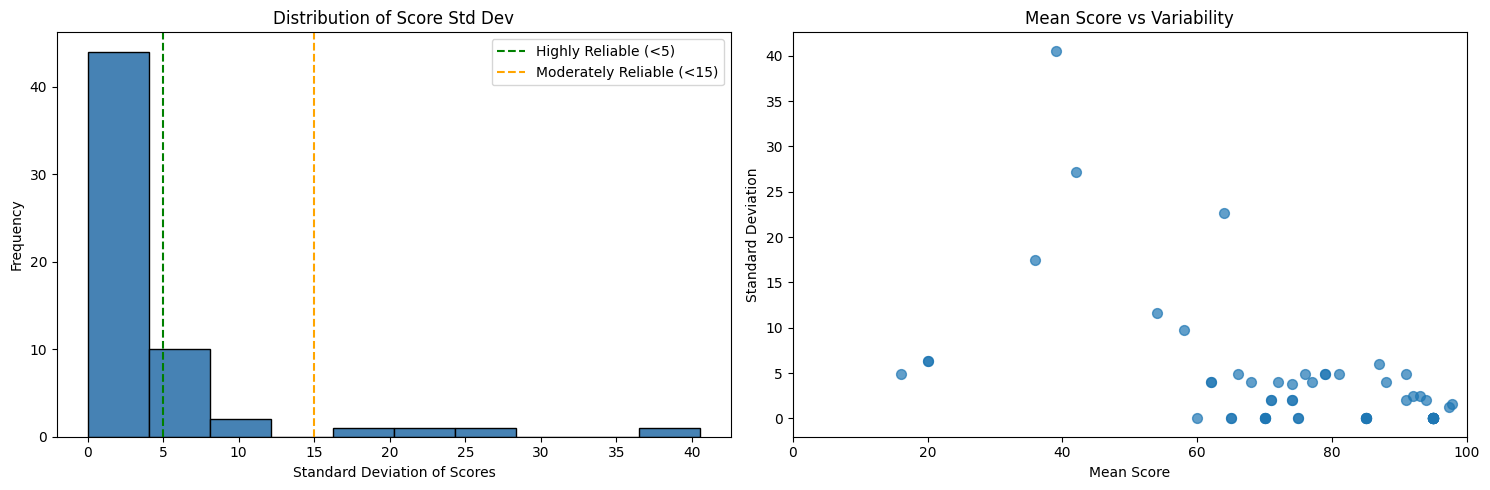

✓ Saved visualization to self_consistency_results.png


In [28]:
# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of standard deviations
axes[0].hist(df_valid['std'], bins=10, edgecolor='black', color='steelblue')
axes[0].axvline(x=5, color='green', linestyle='--', label='Highly Reliable (<5)')
axes[0].axvline(x=15, color='orange', linestyle='--', label='Moderately Reliable (<15)')
axes[0].set_xlabel('Standard Deviation of Scores')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Score Std Dev')
axes[0].legend()


# 3. Mean score vs Std Dev (is there correlation?)
axes[1].scatter(df_valid['mean'], df_valid['std'], alpha=0.7, s=50)
axes[1].set_xlabel('Mean Score')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Mean Score vs Variability')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig('self_consistency_results.png', dpi=150)
plt.show()

print("✓ Saved visualization to self_consistency_results.png")


## Conclusion: Self-Consistency Analysis

### Results Summary

| Prompt Strategy | Mean Std Dev | Interpretation |
|-----------------|--------------|----------------|
| **Few-Shot** | **2.58** | Most deterministic |
| Chain-of-Thought | 4.15 | Moderate variance |
| Zero-Shot | 4.75 | Highest variance |

**Overall mean std across all methods: 3.83**

---

### Key Finding: The Few-Shot Paradox

Few-Shot prompting shows the **lowest variance** (most deterministic), yet in our Prompt Robustness study (3Ba), it produced the **most outliers**. This reveals an important insight:

> **Few-Shot is consistently wrong, not reliably right.**

#### Why Few-Shot Appears "Stable":

1. **Anchoring Effect**: The provided examples act as strong anchors, constraining the model's output distribution. Even at high temperature, the model gravitates toward patterns seen in the examples.

2. **Reduced Exploration**: While Zero-Shot and CoT allow the model to reason freely about each unique comparison, Few-Shot "memorizes" a scoring pattern from the examples—leading to less wandering but also less adaptation.

3. **Overfitting to Examples**: The examples effectively create a narrow prior that the model follows. This reduces variance but introduces **systematic bias** when the test case differs from the example cases.

---

### Comparison with Prompt Robustness (3Ba)

| Metric | Few-Shot | Zero-Shot | CoT |
|--------|----------|-----------|-----|
| **Self-Consistency** (3Bb) | 🥇 Best (2.58) | 🥉 Worst (4.75) | 🥈 Middle (4.15) |
| **Cross-Strategy Agreement** (3Ba) | 🥉 Worst (outliers) | 🥇 Best | 🥇 Best |

**The Paradox Explained:**
- Few-Shot is **internally consistent** (low variance across runs)
- But **externally inconsistent** (disagrees with other methods on certain cases)

This is classic **overfitting behavior**: the model learns the examples too well and fails to generalize.

---

### Recommendation

For an LLM Judge requiring both **stability** and **accuracy**:

| Priority | Recommended Strategy |
|----------|---------------------|
| Need consistent scores across runs | Few-Shot (but watch for bias) |
| Need accurate, generalizable judgments | **Zero-Shot or CoT** |
| Best balance | **Chain-of-Thought** — moderate stability + good generalization |

**Final Verdict:** While Few-Shot wins on determinism, its tendency to anchor on examples makes it unreliable for diverse comparisons. **Chain-of-Thought** offers the best trade-off between consistency and correctness.

## Problematic Comparisons Analysis

Extracting comparisons with high score variance (unreliable judgments).

In [24]:
# Extract Problematic Comparisons (High Variance)
# Threshold: score range > 20 indicates unreliable judgment

VARIANCE_THRESHOLD = 20  # Score range threshold

# Filter problematic pairs
problematic = df_valid[df_valid['range'] > VARIANCE_THRESHOLD].copy()
problematic = problematic.sort_values('range', ascending=False)

print("=" * 70)
print(f"PROBLEMATIC COMPARISONS (Score Range > {VARIANCE_THRESHOLD})")
print("=" * 70)
print(f"\nFound {len(problematic)} problematic comparisons out of {len(df_valid)} total\n")

# Display problematic comparisons
if len(problematic) > 0:
    display_cols = ['event', 'author', 'prompt_type', 'mean', 'std', 'range', 'min', 'max']
    print(problematic[display_cols].to_string(index=False))
    
    # Group by event-author to see which combinations are most problematic
    print("\n" + "=" * 70)
    print("PROBLEMATIC PAIRS BY EVENT & AUTHOR")
    print("=" * 70)
    
    problem_summary = problematic.groupby(['event', 'author']).agg({
        'range': ['max', 'mean', 'count'],
        'prompt_type': lambda x: ', '.join(x)
    }).round(1)
    problem_summary.columns = ['Max Range', 'Avg Range', 'Num Strategies', 'Strategies Affected']
    problem_summary = problem_summary.sort_values('Max Range', ascending=False)
    print(problem_summary.to_string())
    
    # Identify the MOST problematic comparison
    worst = problematic.iloc[0]
    print("\n" + "=" * 70)
    print("🚨 MOST UNRELIABLE COMPARISON:")
    print("=" * 70)
    print(f"   Event:    {worst['event']}")
    print(f"   Author:   {worst['author']}")
    print(f"   Strategy: {worst['prompt_type']}")
    print(f"   Scores:   {worst['scores']}")
    print(f"   Range:    {worst['range']} (min={worst['min']}, max={worst['max']})")
    print(f"   Std Dev:  {worst['std']:.2f}")
else:
    print("✓ No problematic comparisons found! All pairs are reliable.")

PROBLEMATIC COMPARISONS (Score Range > 20)

Found 5 problematic comparisons out of 60 total

                   event                    author      prompt_type  mean       std  range  min  max
      Gettysburg Address John Hay, John G. Nicolay        zero_shot  39.0 40.546270    100    0  100
     Election Night 1860         John T. Morse Jr. chain_of_thought  64.0 22.671568     65   20   85
Second Inaugural Address John Hay, John G. Nicolay        zero_shot  42.0 27.129320     60   20   80
    Fort Sumter Decision John Hay, John G. Nicolay         few_shot  36.0 17.435596     50   20   70
    Fort Sumter Decision         Francis F. Browne chain_of_thought  54.0 11.575837     25   40   65

PROBLEMATIC PAIRS BY EVENT & AUTHOR
                                                    Max Range  Avg Range  Num Strategies Strategies Affected
event                    author                                                                             
Gettysburg Address       John Hay, John G. Nic

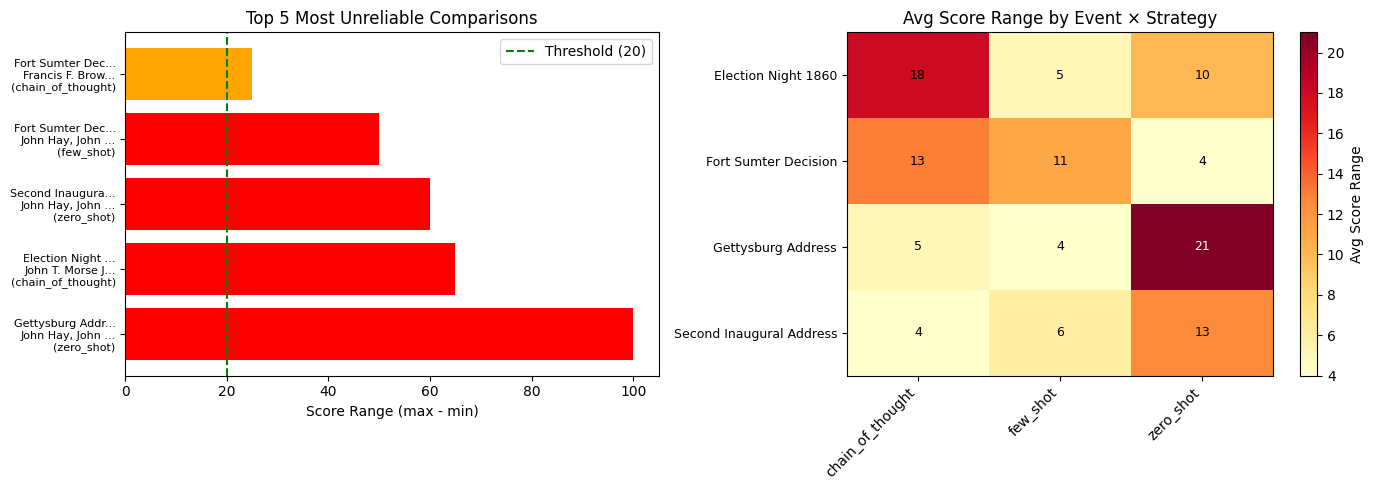


✓ Saved visualization to problematic_comparisons.png


In [26]:
# Visualize Problematic Comparisons
import matplotlib.pyplot as plt

if len(problematic) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Bar chart of problematic pairs by range
    prob_labels = [f"{row['event'][:15]}...\n{row['author'][:15]}...\n({row['prompt_type']})" 
                   for _, row in problematic.head(10).iterrows()]
    colors = ['red' if r >= 50 else 'orange' for r in problematic.head(10)['range']]
    
    axes[0].barh(range(len(prob_labels)), problematic.head(5)['range'], color=colors)
    axes[0].set_yticks(range(len(prob_labels)))
    axes[0].set_yticklabels(prob_labels, fontsize=8)
    axes[0].set_xlabel('Score Range (max - min)')
    axes[0].set_title('Top 5 Most Unreliable Comparisons')
    axes[0].axvline(x=VARIANCE_THRESHOLD, color='green', linestyle='--', label=f'Threshold ({VARIANCE_THRESHOLD})')
    axes[0].legend()
    
    # 2. Heatmap: Event × Prompt Type showing average range
    pivot = df_valid.pivot_table(values='range', index='event', columns='prompt_type', aggfunc='mean')
    im = axes[1].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    axes[1].set_xticks(range(len(pivot.columns)))
    axes[1].set_xticklabels(pivot.columns, rotation=45, ha='right')
    axes[1].set_yticks(range(len(pivot.index)))
    axes[1].set_yticklabels([e[:25] + '...' if len(e) > 25 else e for e in pivot.index], fontsize=9)
    axes[1].set_title('Avg Score Range by Event × Strategy')
    
    # Add annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            color = 'white' if val > 20 else 'black'
            axes[1].text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=9)
    
    plt.colorbar(im, ax=axes[1], label='Avg Score Range')
    plt.tight_layout()
    plt.savefig('problematic_comparisons.png', dpi=150)
    plt.show()
    
    print("\n✓ Saved visualization to problematic_comparisons.png")
else:
    print("No problematic comparisons to visualize.")